1. **Prove** that FD = 1 for a line, FD = 2 for a surface, FD = 3 for random data, and FD > expected when noise is added
2. **Find** the approximate formulas for FD that avoid the exploding nested summation
3. **Test** those formulas and find their limits
4. **Understand and compute** MIC how to compute it ? 
6. **Test** whether summing all MIC values is a good summary, and compare with per-input ranking
8. **Joint FD approach** — generalisation to n inputs and m outputs

In [1]:
# SETUP

## Importation

import subprocess
subprocess.run(["pip", "install", "scikit-dimension", "-q"])

import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

## Definition of functions

# --- FD method 1: Levina-Bickel ---
def levina_bickel(data, k=10):
    
    nn = NearestNeighbors(n_neighbors=k+1)  #détermination of nearest neighbors 
    nn.fit(data)
    distances, _ = nn.kneighbors(data)
    distances = distances[:, 1:]
    #print(distances)
    r_k = distances[:, -1]  #take the neighbor the most far away
    
    estimates = []
    
    for i in range(len(data)):
        if r_k[i] > 0:
            ratio_logs = np.log(r_k[i] / distances[i, :-1])
            if np.all(ratio_logs > 0):
                estimates.append((k - 1) / np.sum(ratio_logs))
    
    return np.mean(estimates)

# --- FD method 2: Two-NN ---

def two_nn(data):   #data is a table with the data to analyse
    nn = NearestNeighbors(n_neighbors=3)  
                                            #we call an object from the class nearest neighbor
                                             # we put 3 and not 2 because the point itself will be counted as a nearest neighbor
    
    nn.fit(data)  #organise les données pour qu'elle soit exploitable et qu'on puisse trouver facilement tous les voisins
    distances, _ = nn.kneighbors(data)
    distances = distances[:, 1:]
    r1 = distances[:, 0]
    r2 = distances[:, 1]
    valid = r1 > 0
    mu = r2[valid] / r1[valid]
    mu_sorted=np.sort(mu)
    N=len(mu_sorted)
    F_emp=np.arange(1,N+1)/N
    mu_sorted=mu_sorted[:-1]
    F_emp=F_emp[:-1]
    
    x=np.log(mu_sorted)
    y=-np.log(1-F_emp)
    d=np.sum(x*y)/np.sum(x**2)
    return d

# --- FD method 3: Grassberger-Procaccia (subsampled) ---
def grassberger_procaccia(data, n_pairs=50000, n_epsilons=20):
    
    N = len(data)
    
    idx1 = np.random.randint(0, N, n_pairs)
    idx2 = np.random.randint(0, N, n_pairs)
    
    valid = idx1 != idx2
    idx1, idx2 = idx1[valid], idx2[valid]
    diffs     = data[idx1] - data[idx2]
    
    distances = np.sqrt(np.sum(diffs**2, axis=1))  #Computation of all the distances
    distances = distances[distances > 0]  #we exclude the distances equal to zero
    
    eps_min  = np.percentile(distances, 5)  #before that the distances can be instable (Claude)
    eps_max  = np.percentile(distances, 50)  #after that the data will not be representative
    epsilons = np.logspace(np.log10(eps_min), np.log10(eps_max), n_epsilons)
    
    C     = np.array([np.mean(distances < eps) for eps in epsilons])
    valid_C = C > 0
    slope, _ = np.polyfit(np.log(epsilons[valid_C]), np.log(C[valid_C]), 1)  #we estimate the slope
    
    return slope



# --- Timer helper ---
def run_and_time(method, data, **kwargs):
    start   = time.time()
    result  = method(data, **kwargs)
    elapsed = time.time() - start
    return result, elapsed

# --- All methods dict ---
all_methods = {
    'Levina-Bickel' : lambda d: levina_bickel(d, k=10),
    'Two-NN'        : two_nn,
    'Grassberger-P' : grassberger_procaccia,
}
method_names = list(all_methods.keys())

colors       = ['steelblue', 'coral', 'green', 'purple', 'orange']


print('Setup complete — all functions loaded.')

Setup complete — all functions loaded.


---
## Point 1 — Prove that FD works

- Completely random data (x, y, z independent) → FD = 3
- Smooth surface z = sin(x·y) → FD = 2
- Straight line → FD = 1
- Line + noise → FD slightly > 1
- Surface + noise → FD slightly > 2

We use **Two-NN** as the primary method (fastest and most accurate in our tests).

In [2]:
### POINT 1 — Proof that FD captures geometric structure using Two_NN method

N = 2000

proof_cases    = {}
proof_expected = {}

# Case 1: straight line (FD should be 1)
t = np.random.uniform(0, 10, N)
proof_cases['Straight line']      = np.column_stack([t, 2*t + 1])
proof_expected['Straight line']   = 1.0

# Case 2: line with noise (FD should be slightly > 1)
t = np.random.uniform(0, 10, N)
proof_cases['Noisy line']         = np.column_stack([t, 2*t + 1 + 0.05*np.random.normal(0,1,N)])
proof_expected['Noisy line']      = 1.2  # approximate

# Case 3: smooth surface (FD should be 2)
x = np.random.uniform(0, 5, N)
y = np.random.uniform(0, 5, N)
proof_cases['Smooth surface']     = np.column_stack([x, y, np.sin(x*y)])
proof_expected['Smooth surface']  = 2.0

# Case 4: noisy surface (FD should be slightly > 2)
x = np.random.uniform(0, 5, N)
y = np.random.uniform(0, 5, N)
proof_cases['Noisy surface']      = np.column_stack([x, y, np.sin(x*y) + 0.3*np.random.normal(0,1,N)])
proof_expected['Noisy surface']   = 2.3  # approximate

# Case 5: completely random (FD should be 3)
proof_cases['Random (x,y,z)']     = np.random.uniform(0, 5, (N, 3))
proof_expected['Random (x,y,z)']  = 3.0

print("Computing FD with Two-NN on all proof cases...\n")
print(f"{'Case':<20} {'Expected':>10} {'Measured':>10} {'Difference':>12} {'Conclusion'}")
print("-" * 72)

for name, data in proof_cases.items():
    fd, _  = run_and_time(two_nn, data)
    diff   = fd - proof_expected[name]
    print(f"{name:<20} {proof_expected[name]:>10.1f} {fd:>10.3f} {diff:>+12.3f}")


Computing FD with Two-NN on all proof cases...

Case                   Expected   Measured   Difference Conclusion
------------------------------------------------------------------------
Straight line               1.0      1.017       +0.017
Noisy line                  1.2      2.118       +0.918
Smooth surface              2.0      2.106       +0.106
Noisy surface               2.3      2.939       +0.639
Random (x,y,z)              3.0      2.936       -0.064


---
### Same proof with Levina-Bickel and Grassberger-Procaccia

To cross-validate, we run the same simple geometries through Levina-Bickel and the subsampled Grassberger-Procaccia estimator.

In [3]:
## POINT 1 bis — Simple geometries with LB + GP


N = 2000

t      = np.random.uniform(0, 10, N)
line   = np.column_stack([t, 2*t + 1])

x, y   = np.random.uniform(0, 5, N), np.random.uniform(0, 5, N)
surface = np.column_stack([x, y, np.sin(x * y)])

x, y   = np.random.uniform(0, 5, N), np.random.uniform(0, 5, N)
noisy  = np.column_stack([x, y, np.sin(x * y) + 0.3 * np.random.normal(0, 1, N)])

random_data = np.random.uniform(0, 5, (N, 3))

cases_1b = {'Line':    (line,        1.0),
            'Surface': (surface,     2.0),
            'Noisy':   (noisy,       2.3),
            'Random':  (random_data, 3.0)}

print(f"{'Case':<12} {'Expected':>9} {'Levina-Bickel':>15} {'Grassberger-P':>15}")
print('-' * 55)

lb_vals, gp_vals, exp_vals, names_1b = [], [], [], []

for name, (data, expected) in cases_1b.items():
    lb = levina_bickel(data, k=10)
    gp = grassberger_procaccia(data)
    print(f"{name:<12} {expected:>9.1f} {lb:>15.3f} {gp:>15.3f}")
    lb_vals.append(lb)
    gp_vals.append(gp)
    exp_vals.append(expected)
    names_1b.append(name)

Case          Expected   Levina-Bickel   Grassberger-P
-------------------------------------------------------
Line               1.0           1.128           0.941
Surface            2.0           2.310           2.166
Noisy              2.3           3.003           2.227
Random             3.0           3.215           2.377


---
## Point 2 — Approximate formulas for FD

The exact Grassberger-Procaccia formula requires computing all N² pairwise distances, impossible for large datasets.
We compare 3 approximate methods and measure their accuracy and speed.

In [4]:
## POINT 2 — Compare all 3 approximate FD methods

#Initialisation

N = 2000

cases    = {}
expected = {}

t = np.random.uniform(0, 10, N)
cases['Line (1D)']              = np.column_stack([t, 2*t + 1])
expected['Line (1D)']           = 1.0

x = np.random.uniform(0, 5, N)
y = np.random.uniform(0, 5, N)
cases['Smooth surface (2D)']    = np.column_stack([x, y, np.sin(x*y)])
expected['Smooth surface (2D)'] = 2.0

x = np.random.uniform(0, 5, N)
y = np.random.uniform(0, 5, N)
cases['Noisy surface (~2.3)']   = np.column_stack([x, y, np.sin(x*y) + 0.3*np.random.normal(0,1,N)])
expected['Noisy surface (~2.3)'] = 2.3

cases['Random 3D']              = np.random.uniform(0, 5, (N, 3))
expected['Random 3D']           = 3.0

t = np.random.uniform(0, 2*np.pi, N)
cases['Curved line 3D (1D)']    = np.column_stack([np.cos(t), np.sin(t), t])
expected['Curved line 3D (1D)'] = 1.0



case_names = list(cases.keys())
results    = {m: {} for m in all_methods}
times      = {m: {} for m in all_methods}
errors     = {m: {} for m in all_methods}

# Computation of all the methods

for name, data in cases.items():
    for mname, mfunc in all_methods.items():
        fd, t = run_and_time(mfunc, data)
        results[mname][name] = fd
        times[mname][name]   = t
        errors[mname][name]  = abs(fd - expected[name]) if not np.isnan(fd) else np.nan


# Summary table

print("=" * 90)
print("RESULTS — Measured FD vs Expected FD")
print("=" * 90)

header = f"{'Case':<24} {'Exp':>5}"
for m in method_names:
    header += f"  {m[:12]:>12}{'Err':>5}"
print(header)
print("-" * 90)

for name in case_names:
    row = f"{name:<24} {expected[name]:>5.1f}"
    for m in method_names:
        row += f"  {results[m][name]:>12.3f} {errors[m][name]:>5.3f}"
    print(row)

print()
print("=" * 60)
print("RANKING — Mean Absolute Error per method (lower = better)")
print("=" * 60)
mae_list = []
for m in method_names:
    errs = [errors[m][n] for n in case_names if not np.isnan(errors[m][n])]
    mae  = np.mean(errs)
    mt   = np.mean(list(times[m].values()))
    mae_list.append((m, mae, mt))
for rank, (m, mae, mt) in enumerate(sorted(mae_list, key=lambda x: x[1])):
    print(f"  #{rank+1}  {m:<20}  MAE = {mae:.3f}   time = {mt:.4f}s")


RESULTS — Measured FD vs Expected FD
Case                       Exp  Levina-Bicke  Err        Two-NN  Err  Grassberger-  Err
------------------------------------------------------------------------------------------
Line (1D)                  1.0         1.127 0.127         1.014 0.014         0.953 0.047
Smooth surface (2D)        2.0         2.340 0.340         2.065 0.065         2.188 0.188
Noisy surface (~2.3)       2.3         2.983 0.683         3.041 0.741         2.211 0.089
Random 3D                  3.0         3.246 0.246         2.979 0.021         2.437 0.563
Curved line 3D (1D)        1.0         1.118 0.118         0.997 0.003         0.960 0.040

RANKING — Mean Absolute Error per method (lower = better)
  #1  Two-NN                MAE = 0.169   time = 0.0014s
  #2  Grassberger-P         MAE = 0.185   time = 0.0026s
  #3  Levina-Bickel         MAE = 0.303   time = 0.0092s


---
## Point 3 — Until what limit are the formulas accurate, by changing the number of points


Varying N (smooth surface, expected FD = 2)

Table of the relative difference with the expected value : FD =2 

N           Levina-Bickel         Two-NN  Grassberger-P
-------------------------------------------------------
100                18.170 %         18.194 %         19.968 %
200                16.130 %          2.002 %          9.156 %
500                15.131 %         11.577 %          4.572 %
1000               17.410 %          2.576 %         10.094 %
2000               16.457 %          3.448 %          9.709 %
5000               14.798 %          0.598 %         10.776 %
10000              12.189 %          2.532 %         10.698 %
20000              12.290 %          0.257 %         10.528 %
30000              12.487 %          1.215 %          9.780 %
40000              12.298 %          1.173 %          8.269 %
50000              12.525 %          0.073 %          9.430 %
70000              12.100 %          0.010 %          8.059 %
100000             12.109 %     

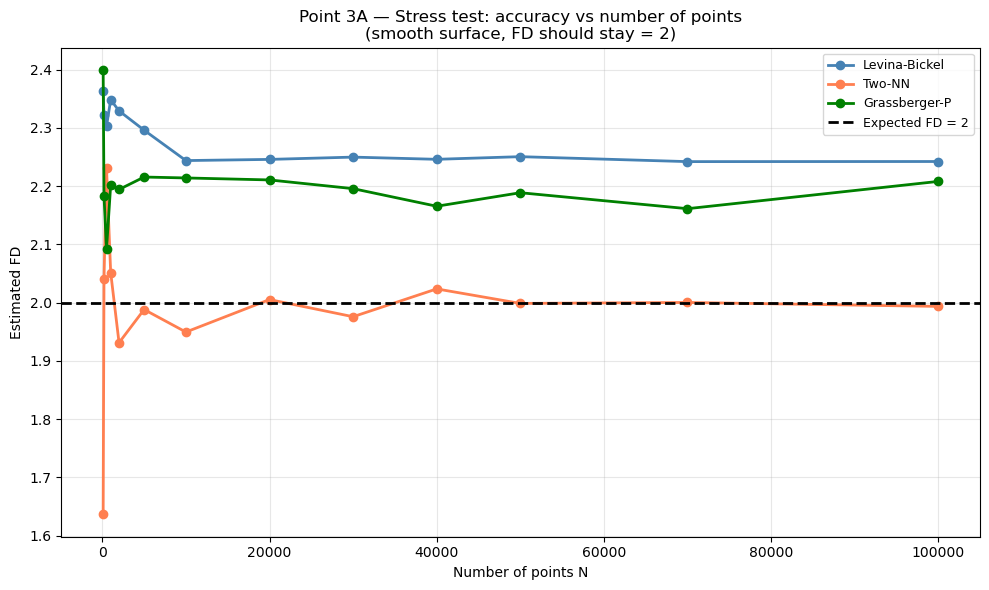


quickly convergence = good 
need many points =bad


In [5]:
# POINT 3A — Accuracy vs number of points N
# Reference: smooth surface, expected FD = 2

N_values       = [100, 200, 500, 1000, 2000, 5000, 10000, 20000, 30000, 40000 ,50000,70000, 100000]
stress_N       = {m: [] for m in all_methods}
RD             =  {m: [] for m in all_methods}

print("Varying N (smooth surface, expected FD = 2)\n")

# Calculations

for N_test in N_values:
    x = np.random.uniform(0, 5, N_test)
    y = np.random.uniform(0, 5, N_test)
    z = np.sin(x * y)
    data_test = np.column_stack([x, y, z])
    for mname, mfunc in all_methods.items():
        fd, t = run_and_time(mfunc, data_test)
        stress_N[mname].append(fd)
        RD[mname].append(np.abs((2-fd)/2)*100)

#Summary table
print("Table of the relative difference with the expected value : FD =2 \n")

print(f"{'N':<10}", end="")
for m in method_names:
    print(f"{m:>15}", end="")
print()
print("-" * (10 + 15 * len(method_names)))

for i, N_test in enumerate(N_values):
    print(f"{N_test:<10}", end="")
    for m in method_names:
        print(f"{RD[m][i]:>15.3f} %", end="")
    print()


# Plot

fig, ax = plt.subplots(figsize=(10, 6))

for i, m in enumerate(method_names):
    ax.plot(N_values, stress_N[m], marker='o', color=colors[i], label=m, linewidth=2)
ax.axhline(y=2.0, color='black', linestyle='--', linewidth=2, label='Expected FD = 2')
ax.set_xlabel('Number of points N')
ax.set_ylabel('Estimated FD')
ax.set_title('Point 3A — Stress test: accuracy vs number of points\n'
             '(smooth surface, FD should stay = 2)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nquickly convergence = good \nneed many points =bad")


In [6]:
# POINT 4 — Demonstrate MIC on simple known cases : How to compute MIC ? 

# MIC = Maximal Information Coefficient

from sklearn.feature_selection import mutual_info_regression

## Definitions
def compute_mic(x, y):
    mi = mutual_info_regression(x.reshape(-1, 1), y, random_state=42)[0]  #Use of mutual_info_regression because our data are continuous
    L= np.sqrt(1 - np.exp(-2 * mi))
    return L

#Parameters

N = 2000
t = np.random.uniform(-3, 3, N)

relationships = {
    'Linear y=2x+1'         : (t, 2*t + 1 + 0.1*np.random.normal(0,1,N)),
    'Quadratic y=x^2'       : (t, t**2    + 0.5*np.random.normal(0,1,N)),
    'Sinusoidal y=sin(3x)'  : (t, np.sin(3*t) + 0.1*np.random.normal(0,1,N)),
    'Pure noise (indep.)'   : (t, np.random.normal(0, 1, N)),
}

print("MIC scores on simple known relationships:\n")
print(f"{'Relationship':<28} {'MIC score':>10} ")
print("-" * 45)

mic_demo   = []
mic_labels = []
for name, (x_val, y_val) in relationships.items():
    score = compute_mic(x_val, y_val)
    mic_demo.append(score)
    mic_labels.append(name)
    print(f"{name:<28} {score:>10.3f} ")


MIC scores on simple known relationships:

Relationship                  MIC score 
---------------------------------------------
Linear y=2x+1                     0.999 
Quadratic y=x^2                   0.976 
Sinusoidal y=sin(3x)              0.983 
Pure noise (indep.)               0.184 


In [7]:
#Test to know which inputs are important to compute the output

#The inputs and the outputs of this cell can change depending on the situation and the studied case

N = 5000
np.random.seed(42)

# Synthetic inputs (mimicking GNN variables)
p     = np.random.uniform(1, 10, N)
T     = np.random.uniform(293, 400, N)
vx    = np.random.uniform(0, 50, N)
vy    = np.random.uniform(0, 50, N)
ft    = np.random.uniform(10, 100, N)
b     = np.random.uniform(0.1, 5, N)
noise = np.random.normal(0, 1, N)       # useless variable

X_norm         = np.column_stack([p, T, vx, vy, ft, b, noise])
variable_names = ['p', 'T', 'vx', 'vy', 'ft', 'b', 'noise']

# Synthetic outputs to test our variables
output_1     = 0.6 * ft * 100 + 0.3 * vx + 0.05 * np.random.normal(0,1,N)  # delta_p: ft and vx
output_2     = 0.7 * (T-293)/10 + 0.4 * b + 0.05 * np.random.normal(0,1,N) # delta_T: T and b
output_3     = 0.5 * vx + 0.5 * vy + 0.05 * np.random.normal(0,1,N)        # delta_v: vx and vy
Y            = np.column_stack([output_1, output_2, output_3])
output_names = ['delta_p', 'delta_T', 'delta_v']

n_inputs  = X_norm.shape[1]
n_outputs = Y.shape[1]

mic_matrix = np.zeros((n_inputs, n_outputs))
for i, iname in enumerate(variable_names):
    for j, oname in enumerate(output_names):
        score              = compute_mic(X_norm[:, i], Y[:, j])
        mic_matrix[i, j]  = score

# Print matrix with row sums
row_sums = mic_matrix.sum(axis=1)
col_sums = mic_matrix.sum(axis=0)

print("=" * 60)
print("DEPENDENCY MATRIX  (rows = inputs, columns = outputs)")
print("=" * 60)

header = f"{'Input':<10}"
for name in output_names:
    header += f"  {name:>10}"
header += f"  {'ROW SUM':>10}"
print(header)

print("-" * 60)
for i, iname in enumerate(variable_names):
    row = f"{iname:<10}"
    for j in range(n_outputs):
        row += f"  {mic_matrix[i, j]:>10.3f}"
    row += f"  {row_sums[i]:>10.3f}"
    print(row)
print("-" * 60)


DEPENDENCY MATRIX  (rows = inputs, columns = outputs)
Input          delta_p     delta_T     delta_v     ROW SUM
------------------------------------------------------------
p                0.000       0.048       0.000       0.048
T                0.000       0.971       0.000       0.971
vx               0.000       0.149       0.795       0.943
vy               0.000       0.138       0.799       0.937
ft               1.000       0.000       0.000       1.000
b                0.000       0.466       0.205       0.671
noise            0.000       0.018       0.000       0.018
------------------------------------------------------------


DEPENDENCY MATRIX  (rows = inputs, columns = outputs)
Input                p           T          vx          vy          ft           b       noise
------------------------------------------------------------
p                1.000       0.000       0.601       0.000       0.089       0.000       0.000
T                0.000       1.000       0.914       0.115       0.000       0.000       0.000
vx               0.601       0.914       1.000       0.144       0.072       0.000       0.197
vy               0.000       0.115       0.144       1.000       0.129       0.000       0.000
ft               0.089       0.000       0.072       0.129       1.000       0.029       0.000
b                0.000       0.000       0.000       0.000       0.029       1.000       0.151
noise            0.000       0.000       0.197       0.000       0.000       0.151       1.000
------------------------------------------------------------


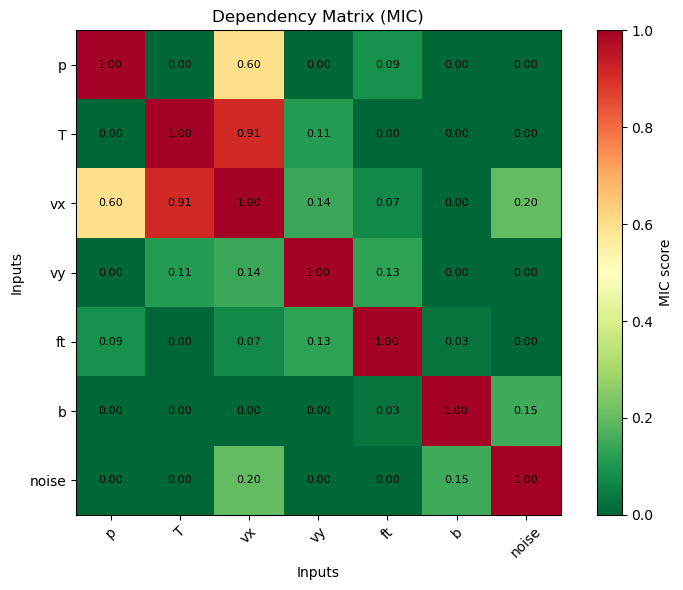

In [8]:
#Test to know which inputs are redundant with other inputs

#The inputs and the outputs of this cell can change depending on the situation and the studied case

## Definitions
def compute_mic(x, y):
    mi = mutual_info_regression(x.reshape(-1, 1), y, random_state=42)[0]  #Use of mutual_info_regression because our data are continuous
    L= np.sqrt(1 - np.exp(-2 * mi))
    return L

N = 5000
np.random.seed(42)

# Synthetic inputs (mimicking GNN variables)
# Inputs are arrays
p     = np.random.uniform(1, 10, N)
T     = np.random.uniform(1, 10, N)
vx    = p + 2*T
vy    = np.random.uniform(0, 50, N)
ft    = np.random.uniform(10, 100, N)
b     = np.random.uniform(0.1, 5, N)
noise = np.random.normal(0, 1, N)       # useless variable

X_norm         = np.column_stack([p, T, vx, vy, ft, b, noise])
variable_names = ['p', 'T', 'vx', 'vy', 'ft', 'b', 'noise']

# Synthetic outputs to test our variables
Y            = np.column_stack([p, T, vx, vy, ft, b, noise])
output_names = ['p', 'T', 'vx', 'vy', 'ft', 'b', 'noise']

n_inputs  = X_norm.shape[1]
n_outputs = Y.shape[1]

mic_matrix = np.zeros((n_inputs, n_outputs))
for i, iname in enumerate(variable_names):
    for j, oname in enumerate(output_names):
        score              = compute_mic(X_norm[:, i], Y[:, j])
        mic_matrix[i, j]  = score

# Print matrix with row sums
row_sums = mic_matrix.sum(axis=1)
col_sums = mic_matrix.sum(axis=0)

print("=" * 60)
print("DEPENDENCY MATRIX  (rows = inputs, columns = outputs)")
print("=" * 60)

header = f"{'Input':<10}"
for name in output_names:
    header += f"  {name:>10}"
print(header)

print("-" * 60)
for i, iname in enumerate(variable_names):
    row = f"{iname:<10}"
    for j in range(n_outputs):
        row += f"  {mic_matrix[i, j]:>10.3f}"
    print(row)
print("-" * 60)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(mic_matrix, cmap='RdYlGn_r', vmin=0, vmax=1)
ax.set_xticks(range(n_outputs))
ax.set_xticklabels(output_names, rotation=45)
ax.set_yticks(range(n_inputs))
ax.set_yticklabels(variable_names)
ax.set_xlabel('Inputs')
ax.set_ylabel('Inputs')
ax.set_title('Dependency Matrix (MIC)')

for i in range(n_inputs):
    for j in range(n_outputs):
        ax.text(j, i, f'{mic_matrix[i,j]:.2f}', ha='center', va='center', fontsize=8)

plt.colorbar(im, label='MIC score')
plt.tight_layout()
plt.show()

Global MIC sum 
We sum the values of the inputs/outputs MIC matrix to see of the data are informative for the outputs (higher is better)
Sum of all 7 x 3 = 21 MIC values : 4.588

Per-input ranking
Rank   Input       Score sum  Bar
---------------------------------------------
1      ft              1.000  ##############
2      T               0.971  ##############
3      vx              0.943  ##############
4      vy              0.937  ##############
5      b               0.671  ##########
6      p               0.048  
7      noise           0.018  

-> By looking at which inputs has the smallest influence on the outputs, you would be able to decide which one should be the one to be removed
-> 'noise' should normally rank last (near-zero score)


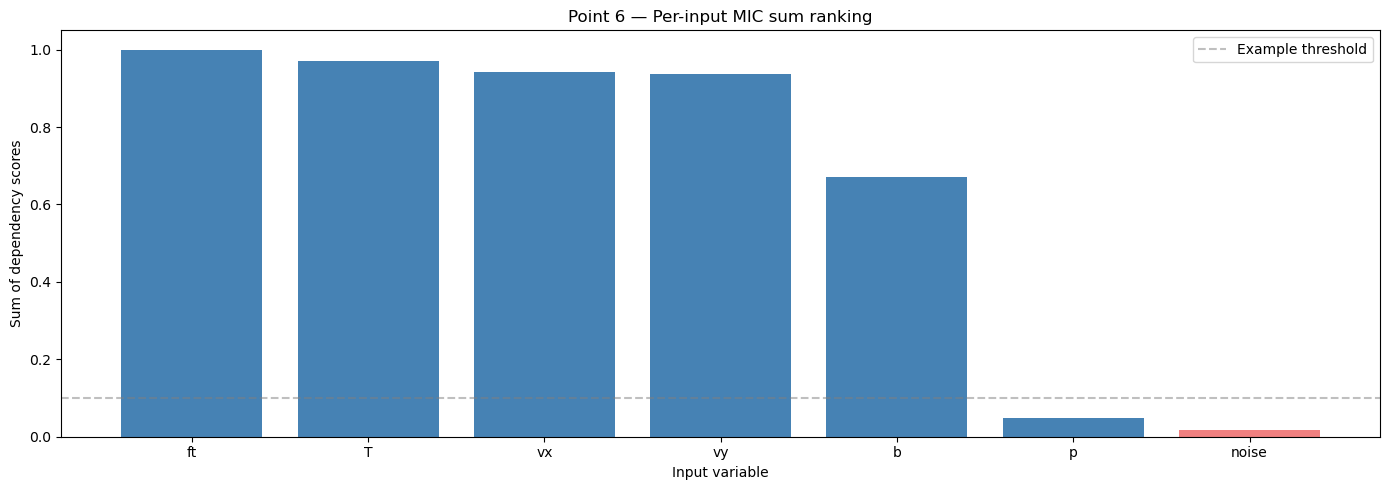


CONCLUSION:
  Global sum : 4.588 — useful as a single quality score
  Per-input ranking       : more informative — shows which variables to keep/remove


In [9]:
# POINT 6 — Global sum and per-input ranking, 
#qualify the usefulness of the inputs to compute the outputs and define which inputs to remove first


N = 5000
np.random.seed(42)


# Synthetic inputs (mimicking GNN variables)
p     = np.random.uniform(1, 10, N)
T     = np.random.uniform(293, 400, N)
vx    = np.random.uniform(0, 50, N)
vy    = np.random.uniform(0, 50, N)
ft    = np.random.uniform(10, 100, N)
b     = np.random.uniform(0.1, 5, N)
noise = np.random.normal(0, 1, N)       # useless variable
X_norm         = np.column_stack([p, T, vx, vy, ft, b, noise])
variable_names = ['p', 'T', 'vx', 'vy', 'ft', 'b', 'noise']


# Synthetic outputs to test our variables
output_1     = 0.6 * ft * 100 + 0.3 * vx + 0.05 * np.random.normal(0,1,N)  # delta_p: ft and vx
output_2     = 0.7 * (T-293)/10 + 0.4 * b + 0.05 * np.random.normal(0,1,N) # delta_T: T and b
output_3     = 0.5 * vx + 0.5 * vy + 0.05 * np.random.normal(0,1,N)        # delta_v: vx and vy
Y            = np.column_stack([output_1, output_2, output_3])
output_names = ['delta_p', 'delta_T', 'delta_v']
n_inputs  = X_norm.shape[1]
n_outputs = Y.shape[1]
mic_matrix = np.zeros((n_inputs, n_outputs))
for i, iname in enumerate(variable_names):
    for j, oname in enumerate(output_names):
        score              = compute_mic(X_norm[:, i], Y[:, j])
        mic_matrix[i, j]  = score
row_sums = mic_matrix.sum(axis=1)               


# --- Global sum ---
global_sum = mic_matrix.sum()
print("=" * 50)
print("Global MIC sum \nWe sum the values of the inputs/outputs MIC matrix to see of the data are informative for the outputs (higher is better)")
print("=" * 50)
print(f"Sum of all {n_inputs} x {n_outputs} = {n_inputs*n_outputs} MIC values : {global_sum:.3f}")
print()


# --- Per-input ranking ---

print("=" * 50)
print("Per-input ranking")
print("=" * 50)
print(f"{'Rank':<6} {'Input':<10} {'Score sum':>10}  {'Bar'}")
print("-" * 45)
sorted_idx = np.argsort(row_sums)[::-1]
for rank, idx in enumerate(sorted_idx):
    bar = '#' * int(row_sums[idx] * 15)
    print(f"{rank+1:<6} {variable_names[idx]:<10} {row_sums[idx]:>10.3f}  {bar}")
print()
print("-> By looking at which inputs has the smallest influence on the outputs, you would be able to decide which one should be the one to be removed")
print("-> 'noise' should normally rank last (near-zero score)")
fig, ax = plt.subplots(figsize=(14, 5))           
bar_colors = ['steelblue' if variable_names[i] != 'noise' else 'lightcoral'
              for i in sorted_idx]
ax.bar([variable_names[i] for i in sorted_idx],    
       row_sums[sorted_idx], color=bar_colors)
ax.set_title('Point 6 — Per-input MIC sum ranking')
ax.set_ylabel('Sum of dependency scores')
ax.set_xlabel('Input variable')
ax.axhline(y=0.1, color='gray', linestyle='--', alpha=0.5, label='Example threshold')
ax.legend()                                       
plt.tight_layout()
plt.show()
print()

# Conclusion
print("CONCLUSION:")
print(f"  Global sum : {global_sum:.3f} — useful as a single quality score")
print(f"  Per-input ranking       : more informative — shows which variables to keep/remove")

In [10]:
# POINT 7 — Generalisation to n inputs and m outputs


N = 10000
n = 7     # number of inputs 
m = 3      # number of outputs

# --- Generate synthetic inputs ---
X_joint = np.random.uniform(0, 5, (N, n))

# --- Generate outputs that DEPEND on inputs ---
# The outputs are deterministic functions of the inputs,
# so the joint dataset (X, Y) should have FD ~ n (not n+m)
Y_joint = np.column_stack([
    np.sin(X_joint[:, 0] * X_joint[:, 1]),    # output 1 depends on inputs 1 and 2
    X_joint[:, 2] + 0.5 * X_joint[:, 3], # output 2 depends on inputs 1 and 3
    np.sin(X_joint[:, 4] * X_joint[:, 5])
])


# --- Build the joint dataset ---
XY = np.column_stack([X_joint, Y_joint])  # shape (N, n+m)

print(f"Input matrix  X  : shape {X_joint.shape}  (n = {n} inputs)")
print(f"Output matrix Y  : shape {Y_joint.shape}  (m = {m} outputs)")
print(f"Joint matrix  XY : shape {XY.shape}  (n+m = {n+m} dimensions)")
print()
print(f"Expected FD ~ {n} (because outputs are determined by inputs)")
print()

# --- Compute FD on the joint dataset ---
fd_lb_joint = levina_bickel(XY, k=10)
fd_gp_joint = grassberger_procaccia(XY)
fd_tnn_joint = two_nn(XY)

print(f"Levina-Bickel    : FD = {fd_lb_joint:.3f}")
print(f"Two-NN           : FD = {fd_tnn_joint:.3f}")
print(f"Grassberger-P    : FD = {fd_gp_joint:.3f}")
print(f"Expected         : FD ~ {n}")
print()

for method_name, fd in [('Levina-Bickel', fd_lb_joint), ('Two-NN', fd_tnn_joint), ('Grassberger-P', fd_gp_joint)]:
    if abs(fd - n) < 1.5:
        print(f"{method_name}: FD ≈ n → good, inputs explain outputs well")
    elif fd < n - 1.5:
        print(f"{method_name}: FD < n → some inputs are probably redundant")
    else:
        print(f"{method_name}: FD >> n → inputs don't fully explain outputs")


Input matrix  X  : shape (10000, 7)  (n = 7 inputs)
Output matrix Y  : shape (10000, 3)  (m = 3 outputs)
Joint matrix  XY : shape (10000, 10)  (n+m = 10 dimensions)

Expected FD ~ 7 (because outputs are determined by inputs)

Levina-Bickel    : FD = 7.931
Two-NN           : FD = 6.780
Grassberger-P    : FD = 4.902
Expected         : FD ~ 7

Levina-Bickel: FD ≈ n → good, inputs explain outputs well
Two-NN: FD ≈ n → good, inputs explain outputs well
Grassberger-P: FD < n → some inputs are probably redundant



PART A : FD vs number of inputs (m=3 outputs fixed)
n inputs   Expected   Two-NN     Lev-Bick   GP        
--------------------------------------------------
2          2          1.982      2.244      2.086     
3          3          2.966      3.415      2.755     
5          5          4.854      5.428      3.858     
7          7          6.629      7.528      4.874     
10         10         9.224      10.163     6.037     
13         13         11.552     12.585     7.062     
16         16         13.988     14.781     8.005     
19         19         15.527     16.937     8.833     
22         22         17.848     19.103     9.605     
25         25         19.621     21.078     10.344    
27         27         21.092     22.219     10.766    


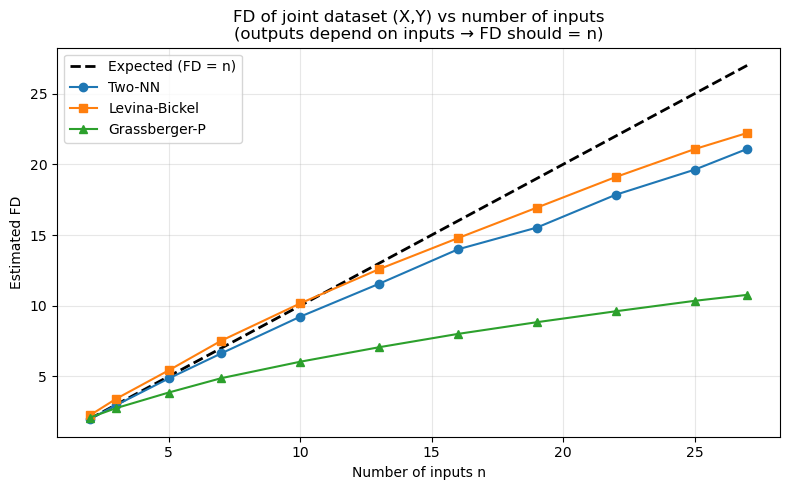


PART B : FD vs number of outputs (n=5 inputs fixed)
m outputs  Expected   Two-NN     Lev-Bick   GP        
--------------------------------------------------
1          5          4.847      5.481      3.869     
2          5          5.079      5.752      4.076     
3          5          4.915      6.039      4.436     
5          5          5.287      6.856      4.905     
8          5          5.425      7.103      5.232     
13         5          5.628      7.365      5.523     
16         5          5.748      7.455      5.621     
18         5          5.870      7.565      5.670     
20         5          5.716      7.534      5.706     
25         5          5.904      7.656      5.678     


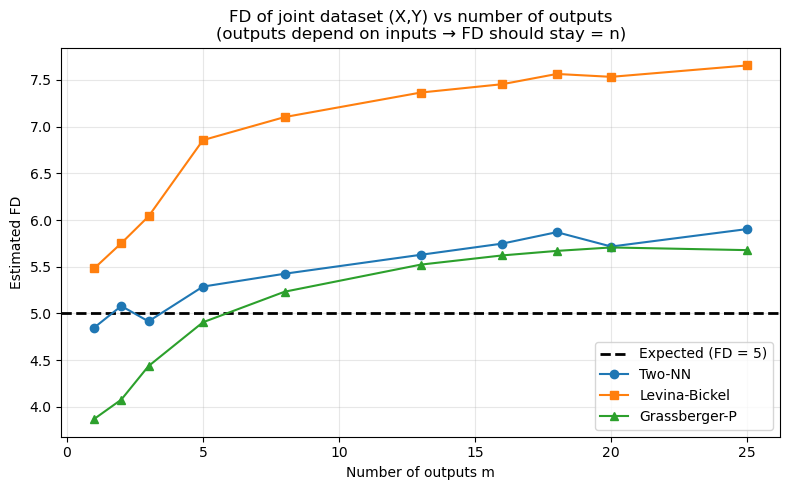

In [11]:
# POINT 7 — FD vs number of inputs, then FD vs number of outputs

N = 10000

# ---- PART A : FD vs number of inputs (m=3 outputs fixed) ----

n_values = [2, 3, 5, 7, 10, 13, 16, 19, 22, 25, 27]
m = 3
fd_tnn_n = []
fd_lb_n  = []
fd_gp_n  = []

for n in n_values:
    X = np.random.uniform(0, 5, (N, n))
    Y = np.column_stack([
        np.sin(X[:, 0] * X[:, 1]),
        X[:, 0] + 0.5 * X[:, min(2, n-1)],
        np.sin(X[:, 0] + X[:, min(3, n-1)])
    ])
    XY = np.column_stack([X, Y])
    fd_tnn_n.append(two_nn(XY))
    fd_lb_n.append(levina_bickel(XY, k=10))
    fd_gp_n.append(grassberger_procaccia(XY))

# Tableau
print("\nPART A : FD vs number of inputs (m=3 outputs fixed)")
print(f"{'n inputs':<10} {'Expected':<10} {'Two-NN':<10} {'Lev-Bick':<10} {'GP':<10}")
print("-" * 50)
for i, n in enumerate(n_values):
    print(f"{n:<10} {n:<10} {fd_tnn_n[i]:<10.3f} {fd_lb_n[i]:<10.3f} {fd_gp_n[i]:<10.3f}")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_values, n_values, 'k--', label='Expected (FD = n)', linewidth=2)
ax.plot(n_values, fd_tnn_n, 'o-', label='Two-NN')
ax.plot(n_values, fd_lb_n, 's-', label='Levina-Bickel')
ax.plot(n_values, fd_gp_n, '^-', label='Grassberger-P')
ax.set_xlabel('Number of inputs n')
ax.set_ylabel('Estimated FD')
ax.set_title('FD of joint dataset (X,Y) vs number of inputs\n(outputs depend on inputs → FD should = n)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---- PART B : FD vs number of outputs (n=5 inputs fixed) ----

n = 5
m_values = [1, 2, 3, 5, 8, 13, 16, 18, 20, 25]
fd_tnn_m = []
fd_lb_m  = []
fd_gp_m  = []

for m in m_values:
    X = np.random.uniform(0, 5, (N, n))
    Y_cols = []
    for j in range(m):
        Y_cols.append(np.sin(X[:, j % n] * X[:, (j+1) % n]))
    Y = np.column_stack(Y_cols)
    XY = np.column_stack([X, Y])
    fd_tnn_m.append(two_nn(XY))
    fd_lb_m.append(levina_bickel(XY, k=10))
    fd_gp_m.append(grassberger_procaccia(XY))

# Tableau
print("\nPART B : FD vs number of outputs (n=5 inputs fixed)")
print(f"{'m outputs':<10} {'Expected':<10} {'Two-NN':<10} {'Lev-Bick':<10} {'GP':<10}")
print("-" * 50)
for i, m in enumerate(m_values):
    print(f"{m:<10} {n:<10} {fd_tnn_m[i]:<10.3f} {fd_lb_m[i]:<10.3f} {fd_gp_m[i]:<10.3f}")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.axhline(y=n, color='k', linestyle='--', label=f'Expected (FD = {n})', linewidth=2)
ax.plot(m_values, fd_tnn_m, 'o-', label='Two-NN')
ax.plot(m_values, fd_lb_m, 's-', label='Levina-Bickel')
ax.plot(m_values, fd_gp_m, '^-', label='Grassberger-P')
ax.set_xlabel('Number of outputs m')
ax.set_ylabel('Estimated FD')
ax.set_title('FD of joint dataset (X,Y) vs number of outputs\n(outputs depend on inputs → FD should stay = n)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
def data_train_FD(data,n,m):
    two_nn(data)
    
    return FD